In [3]:
!pip install nilearn pandas matplotlib seaborn nibabel -q

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

from nilearn import datasets
from nilearn.glm.first_level import FirstLevelModel
from nilearn.plotting import plot_design_matrix, plot_stat_map

In [5]:
haxby = datasets.fetch_haxby()

[fetch_haxby] Added README.md to /root/nilearn_data

[fetch_haxby] Dataset created in /root/nilearn_data/haxby2001

[fetch_haxby] Downloading data from https://www.nitrc.org/frs/download.php/7868/mask.nii.gz ...

[fetch_haxby]  ...done. (0 seconds, 0 min)

[fetch_haxby] Downloading data from http://data.pymvpa.org/datasets/haxby2001/MD5SUMS ...

...

[fetch_haxby] Downloaded 237772800 of 291168628 bytes (81.7%%,    1.6s remaining)

[fetch_haxby] Downloaded 265658368 of 291168628 bytes (91.2%%,    0.8s remaining)

[fetch_haxby]  ...done. (9 seconds, 0 min)

[fetch_haxby] Extracting data from 
/root/nilearn_data/haxby2001/9cabe068089e791ef0c5fe930fc20e30/subj2-2010.01.14.tar.gz...

[fetch_haxby] .. done.

In [6]:
fmri_img = haxby.func[0]
labels_file = haxby.session_target[0]

print(fmri_img)
print(labels_file)

/root/nilearn_data/haxby2001/subj2/bold.nii.gz
/root/nilearn_data/haxby2001/subj2/labels.txt


In [7]:
labels = pd.read_csv(labels_file, sep=" ")
labels.head()

,labels,chunks
0,rest,0
1,rest,0
2,rest,0
3,rest,0
4,rest,0


In [8]:
task_labels = labels[
    ~labels["labels"].isin(["rest", "fixation"])
].copy()

task_labels.head()

,labels,chunks
6,scissors,0
7,scissors,0
8,scissors,0
9,scissors,0
10,scissors,0


In [9]:
events = pd.DataFrame({
    "onset": task_labels["chunks"] * 2.5,
    "duration": 2.5,
    "trial_type": task_labels["labels"]
})

events.head()

,onset,duration,trial_type
6,0.0,2.5,scissors
7,0.0,2.5,scissors
8,0.0,2.5,scissors
9,0.0,2.5,scissors
10,0.0,2.5,scissors


In [10]:
glm = FirstLevelModel(
    t_r=2.5,
    hrf_model="spm",
    drift_model="cosine",
    high_pass=0.01,
    smoothing_fwhm=6
)

glm = glm.fit(fmri_img, events=events)

/tmp/ipykernel_7640/2956545774.py:9: UserWarning: Duplicated events were detected. Amplitudes of these events will be summed. You might want to verify your inputs.
  glm = glm.fit(fmri_img, events=events)
/tmp/ipykernel_7640/2956545774.py:9: UserWarning: Matrix is singular at working precision, regularizing...
  glm = glm.fit(fmri_img, events=events)


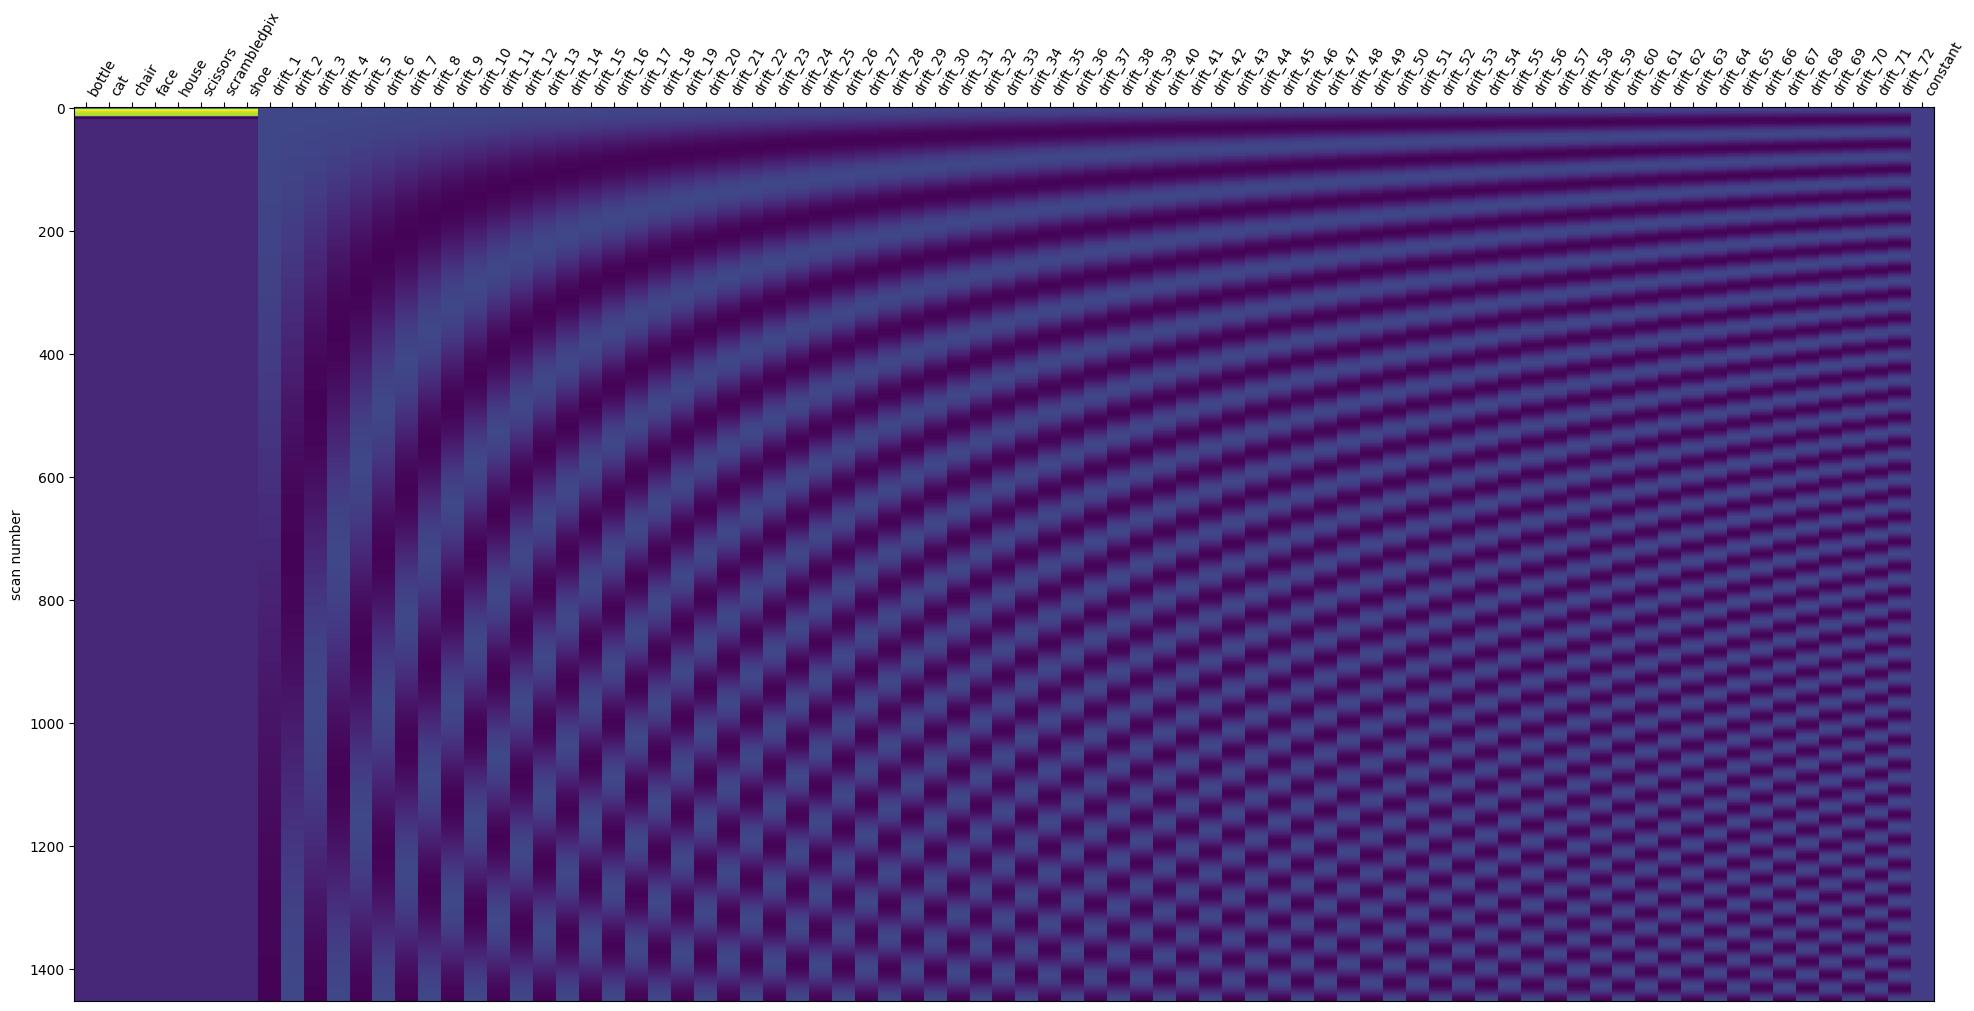

In [11]:
design_matrix = glm.design_matrices_[0]

plot_design_matrix(design_matrix)
plt.show()

In [12]:
print(design_matrix.columns.tolist())

['bottle', 'cat', 'chair', 'face', 'house', 'scissors', 'scrambledpix', 'shoe', 'drift_1', 'drift_2', 'drift_3', 'drift_4', 'drift_5', 'drift_6', 'drift_7', 'drift_8', 'drift_9', 'drift_10', 'drift_11', 'drift_12', 'drift_13', 'drift_14', 'drift_15', 'drift_16', 'drift_17', 'drift_18', 'drift_19', 'drift_20', 'drift_21', 'drift_22', 'drift_23', 'drift_24', 'drift_25', 'drift_26', 'drift_27', 'drift_28', 'drift_29', 'drift_30', 'drift_31', 'drift_32', 'drift_33', 'drift_34', 'drift_35', 'drift_36', 'drift_37', 'drift_38', 'drift_39', 'drift_40', 'drift_41', 'drift_42', 'drift_43', 'drift_44', 'drift_45', 'drift_46', 'drift_47', 'drift_48', 'drift_49', 'drift_50', 'drift_51', 'drift_52', 'drift_53', 'drift_54', 'drift_55', 'drift_56', 'drift_57', 'drift_58', 'drift_59', 'drift_60', 'drift_61', 'drift_62', 'drift_63', 'drift_64', 'drift_65', 'drift_66', 'drift_67', 'drift_68', 'drift_69', 'drift_70', 'drift_71', 'drift_72', 'constant']


In [13]:
contrast = "face - house"

z_map = glm.compute_contrast(
    contrast,
    output_type="z_score"
)

/usr/local/lib/python3.12/dist-packages/nilearn/glm/model.py:205: RuntimeWarning: invalid value encountered in sqrt
  sd = np.sqrt(self.vcov(matrix=matrix, dispersion=dispersion))
/usr/local/lib/python3.12/dist-packages/nilearn/glm/_utils.py:207: RuntimeWarning: divide by zero encountered in divide
  return np.where(X <= 0, 0, 1.0 / X)


/tmp/ipykernel_7640/2033004248.py:1: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  plot_stat_map(


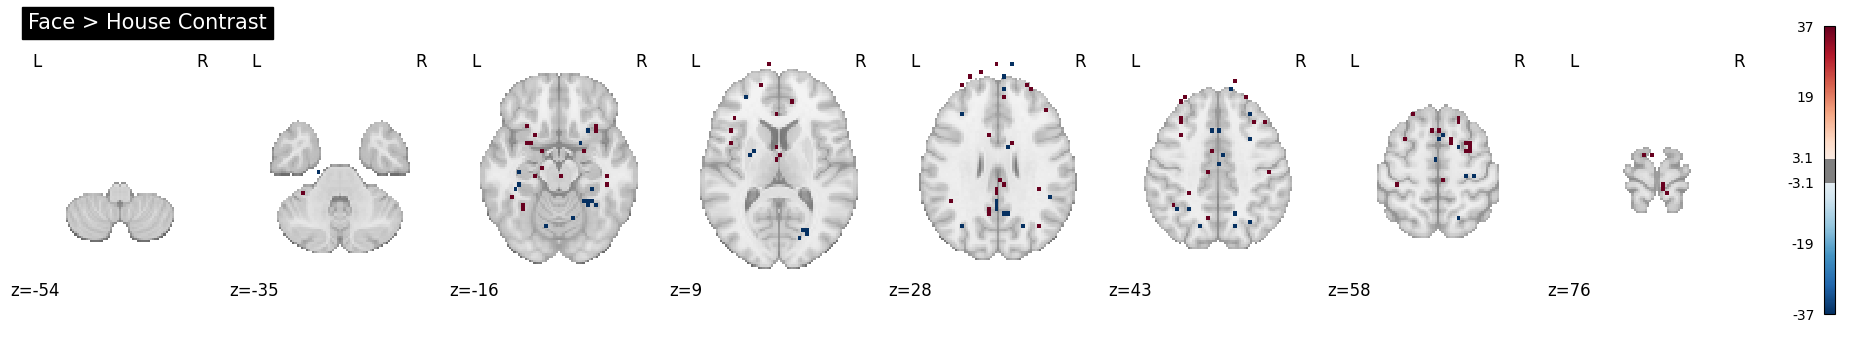

In [14]:
plot_stat_map(
    z_map,
    threshold=3.1,
    display_mode="z",
    cut_coords=8,
    title="Face > House Contrast"
)

plt.show()

/tmp/ipykernel_7640/1934858458.py:5: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  fig = plot_stat_map(


Saved figure


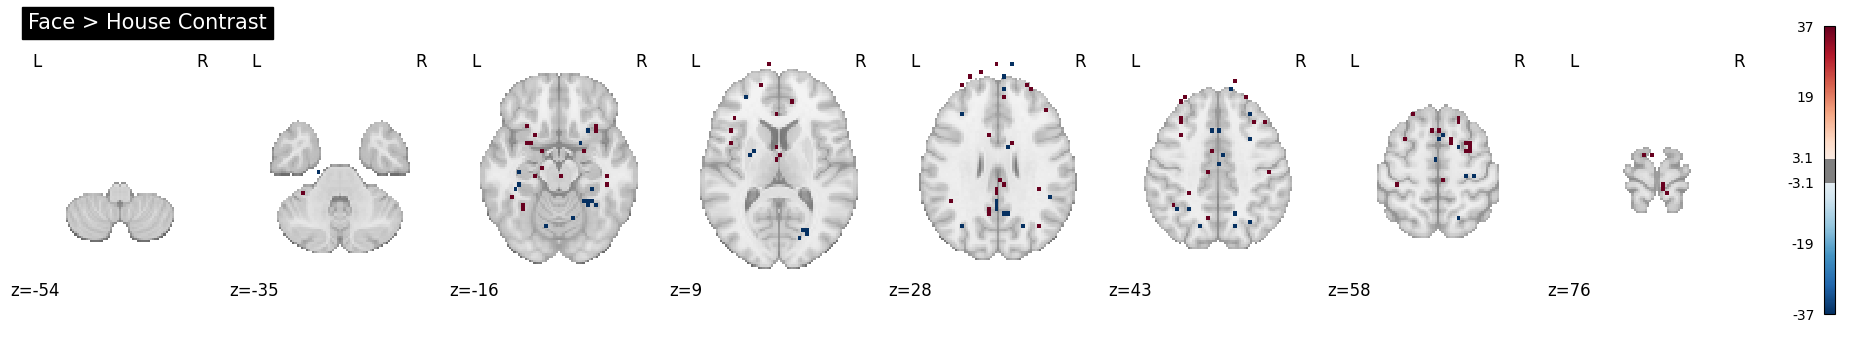

In [16]:
import os

os.makedirs("figures", exist_ok=True)

fig = plot_stat_map(
    z_map,
    threshold=3.1,
    display_mode="z",
    cut_coords=8,
    title="Face > House Contrast"
)

fig.savefig("figures/first_level_face_vs_house.png")
print("Saved figure")